# TP1 -- Regresion e Introduccion a la evaluacion de modelos

**Materia:** 72.75 Aprendizaje Automatico (Machine Learning) -- ITBA

## 1. Alcance del proyecto

El objetivo de este trabajo practico es implementar modelos de regresion para predecir la
**calidad del vino** (variable numerica, escala 0-10) a partir de sus propiedades
fisicoquimicas, utilizando el dataset *Wine Quality* (Cortez et al., 2009).

El trabajo abarca:

1. **Limpieza de datos:** analisis de variables categoricas, valores faltantes, outliers
   y seleccion de caracteristicas.
2. **Regresion lineal:** separacion train/test, validacion cruzada k-fold, entrenamiento
   y evaluacion con RMSE.
3. **Regresion polinomica:** transformacion polinomica de las variables de entrada,
   entrenamiento y regularizacion L1 (Lasso).
4. **Evaluacion y comparacion** de los modelos entrenados.

## 2. Composicion del dataset

El dataset proviene del UCI Machine Learning Repository y fue creado por Paulo Cortez
(Univ. Minho) en 2009. Contiene muestras de vino portugues de la denominacion de origen
*Vinho Verde*, separadas en dos archivos: **vinos tintos** (1599 muestras) y **blancos**
(4898 muestras).

Cada muestra tiene **11 variables de entrada** basadas en tests fisicoquimicos y
**1 variable de salida** basada en evaluacion sensorial (mediana de al menos 3 expertos):

| # | Variable | Descripcion |
|---|----------|-------------|
| 1 | fixed acidity | Acidez fija (g/L acido tartarico) |
| 2 | volatile acidity | Acidez volatil (g/L acido acetico) |
| 3 | citric acid | Acido citrico (g/L) |
| 4 | residual sugar | Azucar residual (g/L) |
| 5 | chlorides | Cloruros (g/L NaCl) |
| 6 | free sulfur dioxide | SO2 libre (mg/L) |
| 7 | total sulfur dioxide | SO2 total (mg/L) |
| 8 | density | Densidad (g/cm3) |
| 9 | pH | pH |
| 10 | sulphates | Sulfatos (g/L K2SO4) |
| 11 | alcohol | Alcohol (% vol) |
| **12** | **quality** | **Calidad (score 0-10) -- variable target** |

El dataset no contiene valores faltantes.

## 3. Variable categorica: tipo de vino

Al unir los dos archivos, surge una unica variable categorica: el **tipo de vino**
(tinto o blanco). Las distribuciones de varias propiedades difieren significativamente
entre ambos tipos (por ejemplo, la acidez volatil promedio es 0.53 en tintos vs 0.28
en blancos), por lo que incluir esta variable como feature aporta informacion relevante
para el modelo.

Para poder utilizarla en modelos de regresion, aplicamos **One-Hot Encoding** con
`drop_first=True`. Como la variable tiene solo dos categorias, el OHE produce una
unica columna binaria: `red_wine_type`.

- `red_wine_type = 1` indica vino tinto
- `red_wine_type = 0` indica vino blanco

No se necesita una segunda columna (`white_wine_type`) porque seria linealmente
dependiente (`white = 1 - red`), lo cual introduciria multicolinealidad perfecta
y perjudicaria a los modelos de regresion lineal.

## 4. Carga y preparacion del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
red   = pd.read_csv("data/raw/winequality-red.csv",   sep=";")
white = pd.read_csv("data/raw/winequality-white.csv", sep=";")

red["red_wine_type"]   = 1
white["red_wine_type"] = 0

df = pd.concat([red, white], ignore_index=True)

print(f"Tintos:  {len(red):,} muestras")
print(f"Blancos: {len(white):,} muestras")
print(f"Total:   {len(df):,} muestras")

Tintos:  1,599 muestras
Blancos: 4,898 muestras
Total:   6,497 muestras


In [3]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,red_wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,1
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,1
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,1
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,1


In [4]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,red_wine_type
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818,0.246
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873,0.431
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000,0.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000,0.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000,0.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000,0.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000,1.000


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
red_wine_type           0
dtype: int64

## 5. Distribucion de las variables

### Tipo de vino

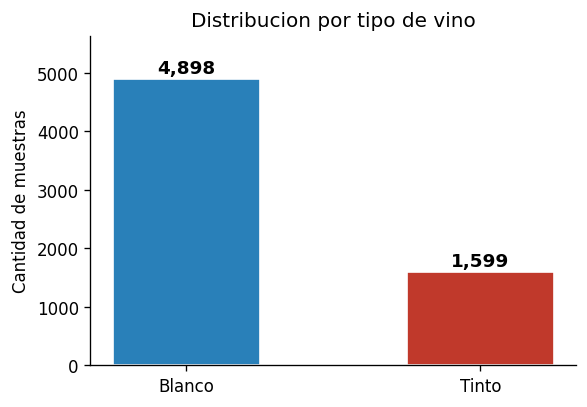

In [6]:
counts = df["red_wine_type"].value_counts().sort_index()
labels = ["Blanco", "Tinto"]
colors = ["#2980B9", "#C0392B"]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Cantidad de muestras")
ax.set_title("Distribucion por tipo de vino")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

### Histogramas con curva de Gauss ajustada

Para cada variable numerica se grafica el histograma normalizado junto con la curva
de distribucion normal ajustada (misma media y desvio estandar que los datos).
Esto permite visualizar que tan cerca esta cada variable de una distribucion normal.

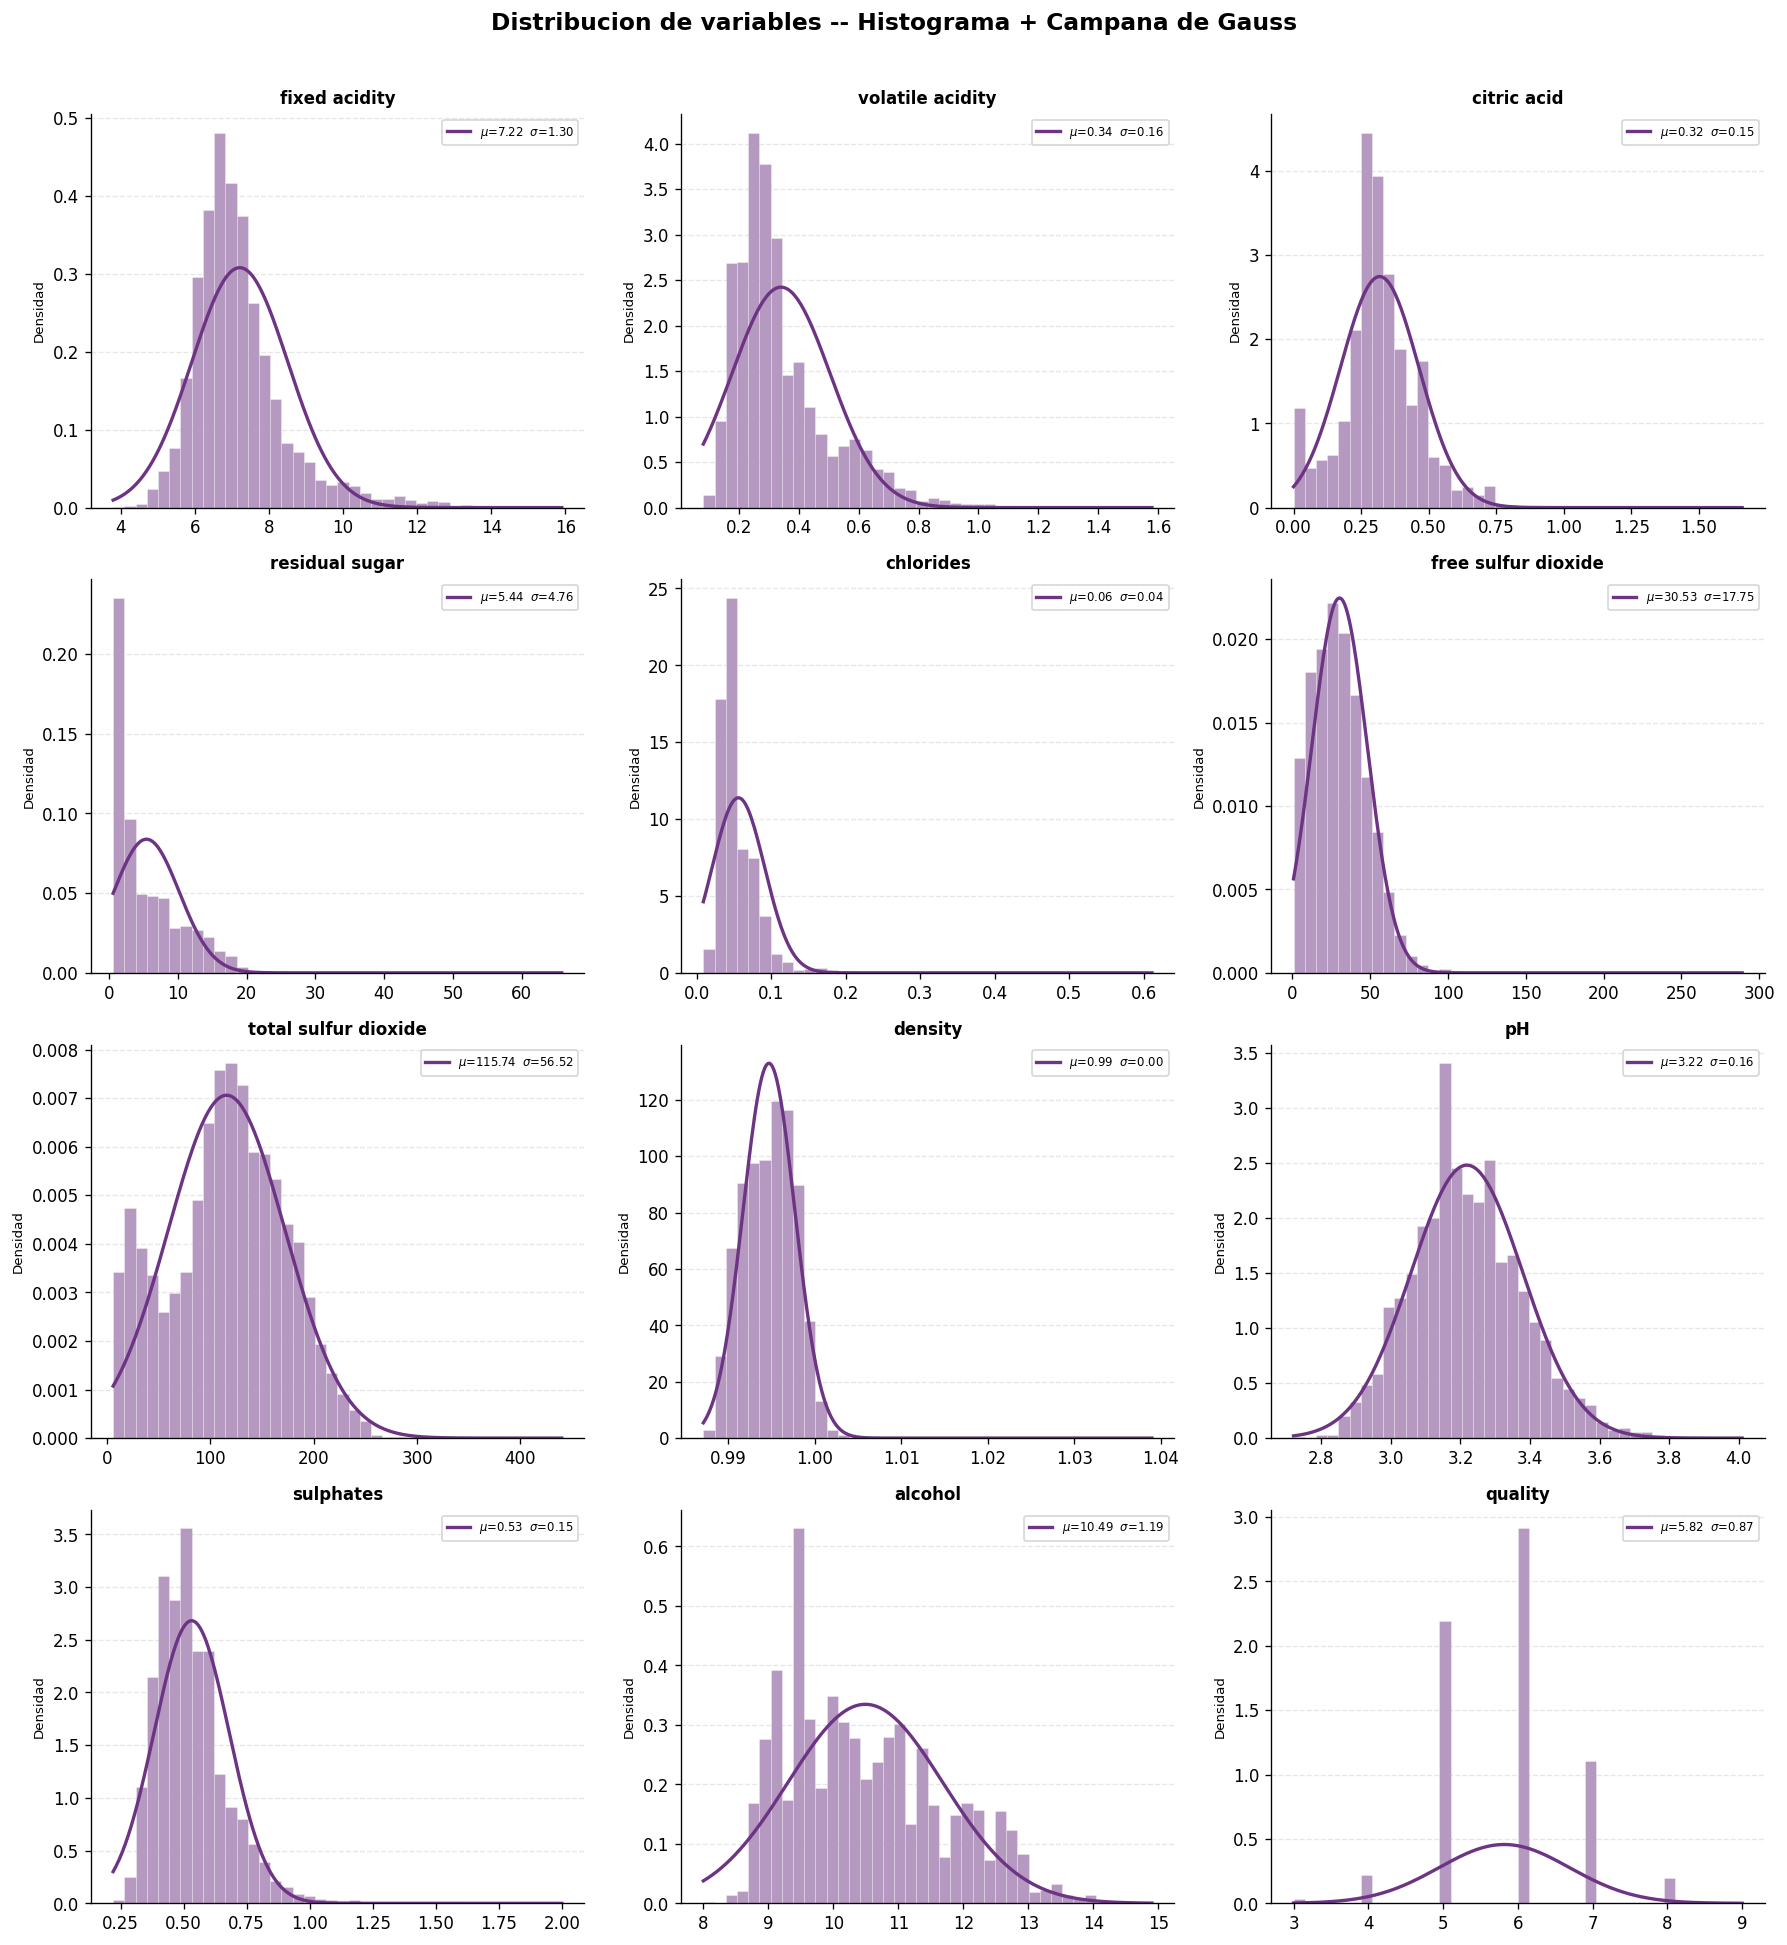

In [7]:
features = [c for c in df.columns if c != "red_wine_type"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle("Distribucion de variables -- Histograma + Campana de Gauss", fontsize=14, fontweight="bold", y=1.01)

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    vals = df[feat].dropna()

    ax.hist(vals, bins=40, density=True, color="#6C3483", alpha=0.5,
            edgecolor="white", linewidth=0.4)

    mu, sigma = vals.mean(), vals.std()
    x = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="#6C3483", linewidth=2,
            label=f"$\mu$={mu:.2f}  $\sigma$={sigma:.2f}")

    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_ylabel("Densidad", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Boxplots

Los boxplots permiten identificar visualmente la dispersion, la mediana y los valores
atipicos (puntos fuera de los bigotes, calculados como 1.5 veces el rango intercuartilico).

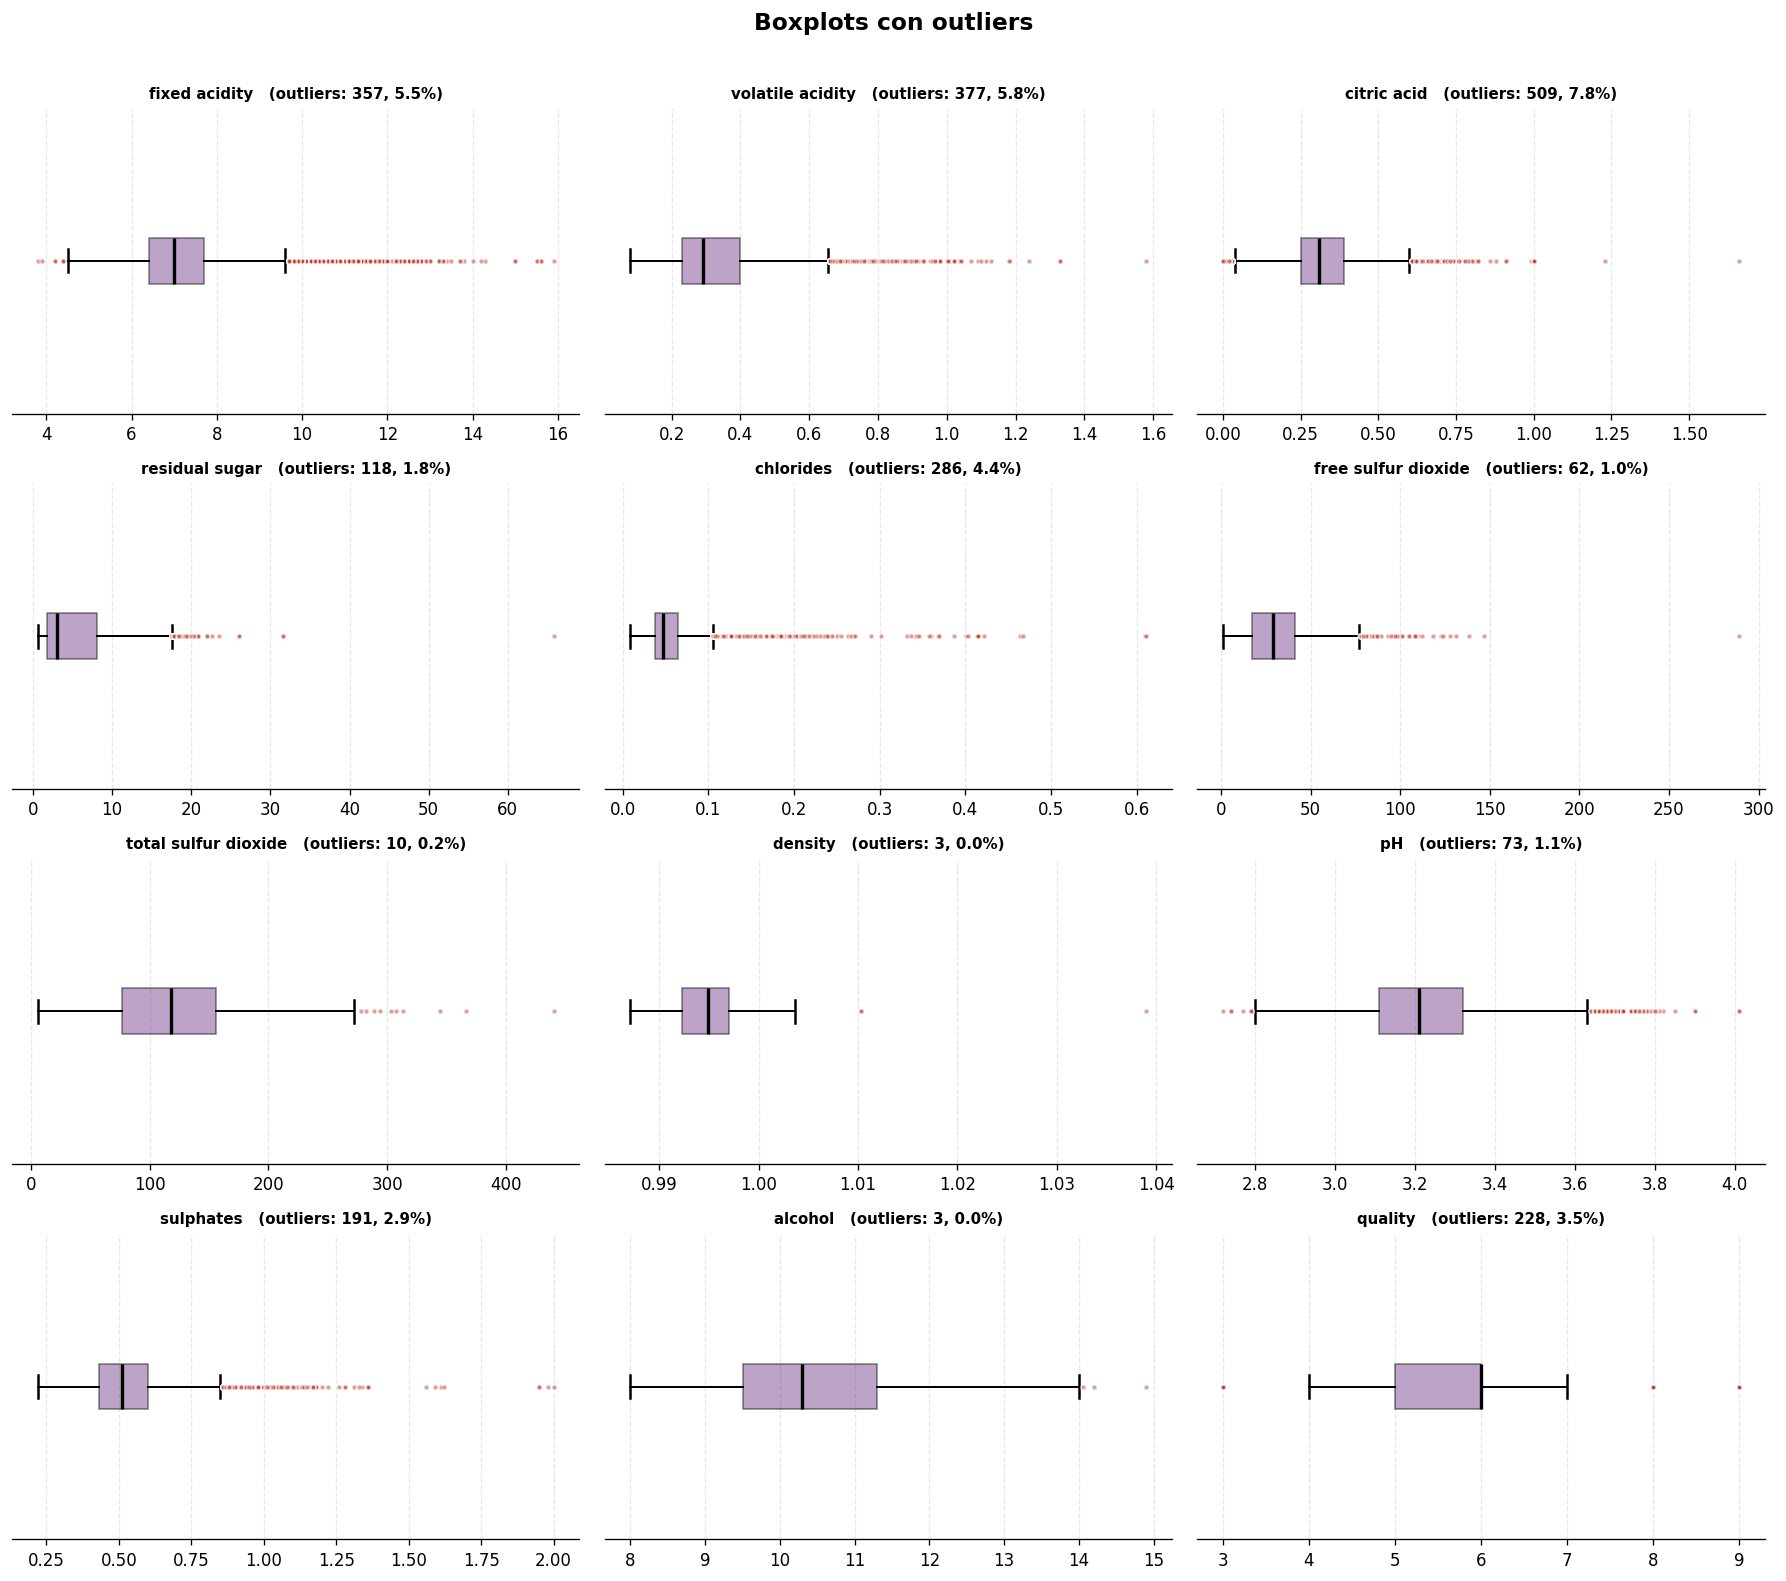

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
fig.suptitle("Boxplots con outliers", fontsize=14, fontweight="bold", y=1.01)

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    vals = df[feat].dropna()

    bp = ax.boxplot(vals, vert=False, patch_artist=True,
                    flierprops=dict(marker="o", markerfacecolor="#C0392B",
                                   markeredgecolor="white", markersize=3, alpha=0.5),
                    medianprops=dict(color="black", linewidth=2),
                    boxprops=dict(facecolor="#6C3483", alpha=0.45),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.5))

    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    pct = 100 * len(outliers) / len(vals)

    ax.set_title(f"{feat}   (outliers: {len(outliers)}, {pct:.1f}%)",
                 fontsize=9, fontweight="bold")
    ax.set_yticks([])
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Analisis de outliers

Distinguimos dos tipos de outliers y les damos tratamiento diferente:

### 6.1 Valores erroneos (eliminacion de filas)

Son valores **fisicamente imposibles, regulatoriamente ilegales, o indicativos de error
de medicion**. Se eliminan las filas completas porque no representan vinos reales:

| Variable | Criterio | Filas | Justificacion |
|----------|----------|-------|---------------|
| `total sulfur dioxide` | > 300 mg/L | 6 | La regulacion de la UE (Reg. 2019/934) establece maximos de 150 mg/L (tinto) y 200 mg/L (blanco), con excepciones hasta 300. Valores de 313-440 mg/L son ilegales y toxicos. |
| `free sulfur dioxide` | > 150 mg/L | 1 | El SO2 libre raramente supera 80-100 mg/L en practica enologica. El valor de 289 mg/L es incoherente (la misma fila tiene SO2 total = 440). |
| `chlorides` | > 0.3 g/L | 24 | El rango normal es 0.01-0.10 g/L. Valores de 0.30-0.61 son 3x-6x el maximo normal y sugieren contaminacion o error de unidades. |
| `citric acid` | > 1.0 g/L | 2 | El rango natural es 0-0.5 g/L, con limite legal de adicion de 1.0 g/L. El valor de 1.66 g/L excede ambos limites. |
| `density` | > 1.010 g/cm3 | 3 | Densidades de 1.01-1.04 corresponden a vinos de postre con alto azucar (31-65 g/L), incompatible con Vinho Verde que es seco/semi-seco. |
| `pH` | < 2.80 | 7 | El pH del vino esta entre 3.0 y 4.0. Valores de 2.72-2.79 son comparables al vinagre y no representan vino comercializable. |

**Total: 41 filas a eliminar (0.63% del dataset).** Algunas filas acumulan multiples
anomalias (ej: fila con chlorides=0.611 y pH=2.74), lo que refuerza la hipotesis de
error sistematico.

In [9]:
erroneous = (
    (df["total sulfur dioxide"] > 300) |
    (df["free sulfur dioxide"] > 150) |
    (df["chlorides"] > 0.3) |
    (df["citric acid"] > 1.0) |
    (df["density"] > 1.01) |
    (df["pH"] < 2.80)
)

print(f"Filas erroneas detectadas: {erroneous.sum()}")
print(f"Filas restantes:           {(~erroneous).sum()} ({100*(~erroneous).sum()/len(df):.1f}%)")

Filas erroneas detectadas: 41
Filas restantes:           6456 (99.4%)


In [10]:
df[erroneous].describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,red_wine_type
count,41.000,41.000,41.00,41.000,41.000,41.000,41.000,41.000,41.000,41.000,41.000,41.000,41.000
mean,8.217,0.443,0.50,6.295,0.257,35.085,123.561,0.998,3.064,0.879,9.849,5.220,0.537
std,0.988,0.192,0.29,11.814,0.187,50.794,112.316,0.008,0.184,0.416,0.943,0.852,0.505
min,6.100,0.170,0.20,1.000,0.022,5.000,10.000,0.990,2.720,0.370,8.800,3.000,0.000
25%,7.600,0.270,0.28,1.700,0.053,12.000,51.000,0.995,3.000,0.520,9.200,5.000,0.000
50%,8.000,0.430,0.48,2.000,0.341,17.000,67.000,0.997,3.060,0.710,9.400,5.000,1.000
75%,8.700,0.550,0.66,4.600,0.413,35.000,176.000,0.998,3.170,1.170,10.500,6.000,1.000
max,11.000,0.965,1.66,65.800,0.611,289.000,440.000,1.039,3.440,2.000,13.100,7.000,1.000


### 6.2 Outliers estadisticos (winsorizacion)

Para los valores que son **quimicamente posibles** pero estadisticamente extremos,
no se eliminan filas. En su lugar se aplica **winsorizacion al rango [percentil 1,
percentil 99]**: los valores por debajo del p1 se reemplazan por el p1, y los valores
por encima del p99 se reemplazan por el p99.

Se eligio winsorizacion en lugar de eliminacion porque:

- **Preserva el tamano muestral:** una fila puede ser outlier en una variable pero
  perfectamente normal en las demas. Eliminarla descartaria toda esa informacion.
- **Preserva la forma de la distribucion:** solo se aplastan las colas extremas,
  sin alterar la estructura central de los datos.
- **Es mas robusta que imputar por media/mediana:** la media ignora la posicion del
  valor original; la winsorizacion lo ancla al extremo mas cercano de la distribucion real.

Las variables a winsorizar son aquellas con **skewness alta y muchos outliers por IQR**
tras la eliminacion de valores erroneos:

| Variable | Skewness | Outliers IQR | Accion |
|----------|----------|-------------|--------|
| `residual sugar` | 1.44 | ~2% | Winsorizar al p1-p99 |
| `volatile acidity` | 1.50 | ~6% | Winsorizar al p1-p99 |
| `sulphates` | 1.80 | ~3% | Winsorizar al p1-p99 |
| `chlorides` | 5.40 | ~4% | Winsorizar al p1-p99 (post-eliminacion de > 0.3) |
| `alcohol` | 0.57 | ~0% | No winsorizar |
| `pH` | 0.39 | ~1% | No winsorizar |
| `density` | 0.50 | ~0% | No winsorizar |
| **`quality`** | **0.19** | **~4%** | **No tocar: es la variable target** |

La variable target (`quality`) nunca se modifica: los vinos de calidad 3 o 9 son raros
pero representan exactamente los extremos que el modelo necesita aprender a predecir.

## 7. Correlacion entre variables

Visualizamos la matriz de correlacion de Pearson para identificar:

- **Variables altamente correlacionadas entre si** (candidatas a descarte por redundancia).
- **Variables correlacionadas con `quality`** (las mas utiles como predictores).

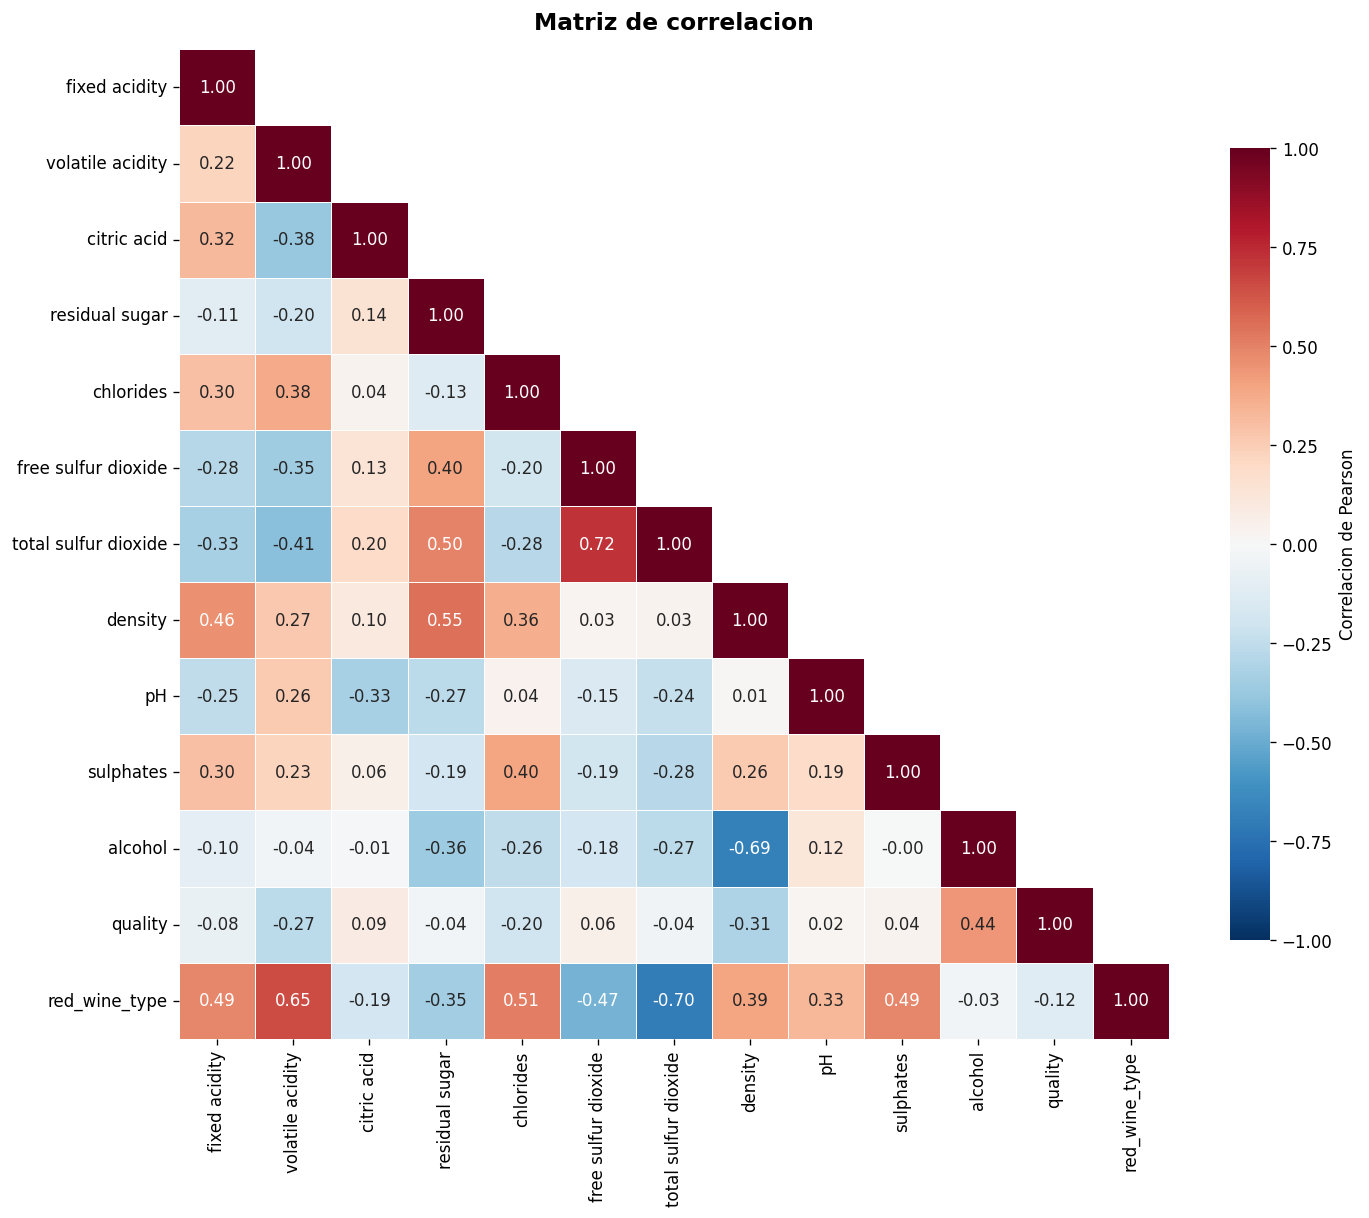

In [11]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlacion de Pearson"},
            ax=ax)
ax.set_title("Matriz de correlacion", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [12]:
quality_corr = corr["quality"].drop("quality").sort_values(key=abs, ascending=False)
print("Correlacion con quality (ordenada por valor absoluto):\n")
print(quality_corr.round(3).to_string())

Correlacion con quality (ordenada por valor absoluto):

alcohol                 0.444
density                -0.306
volatile acidity       -0.266
chlorides              -0.201
red_wine_type          -0.119
citric acid             0.086
fixed acidity          -0.077
free sulfur dioxide     0.055
total sulfur dioxide   -0.041
sulphates               0.038
residual sugar         -0.037
pH                      0.020


### Observaciones sobre la correlacion

**Pares altamente correlacionados entre si:**

- `density` y `residual sugar` (r ~ 0.55): la densidad del vino aumenta con el contenido
  de azucar. Es una relacion fisica directa.
- `density` y `alcohol` (r ~ -0.69): el alcohol es menos denso que el agua, por lo que
  a mayor graduacion, menor densidad. Otra relacion fisica directa.
- `free sulfur dioxide` y `total sulfur dioxide` (r ~ 0.62): el SO2 libre es una fraccion
  del total, por lo que la correlacion es esperada.
- `fixed acidity` y `pH` (r ~ -0.43): mayor acidez fija implica menor pH por definicion.

**Correlacion con `quality` (variable target):**

- `alcohol` muestra la correlacion mas fuerte con la calidad (~0.44).
- `volatile acidity` tiene correlacion negativa relevante (~-0.27): una alta acidez
  volatil se percibe como defecto (aroma avinagrado).
- `density` tiene correlacion negativa (~-0.31), posiblemente mediada por su relacion
  con el alcohol.

**Decision:** No descartamos ninguna variable en esta etapa. Si bien algunos pares tienen
correlacion moderada-alta, ninguno supera |r| > 0.80, que es el umbral tipico para
considerar que una variable es redundante. Ademas, la regresion polinomica y la
regularizacion L1 (Lasso) que se usaran mas adelante pueden manejar la multicolinealidad
moderada de forma efectiva, penalizando automaticamente las variables redundantes.

## 8. Eliminacion de valores erroneos

Aplicamos el primer paso de limpieza: eliminar las 41 filas con valores fisicamente
imposibles o regulatoriamente ilegales (criterios de la seccion 6.1).

Estos criterios son **umbrales fijos** derivados de conocimiento del dominio (limites
legales de SO2, rangos quimicos del vino, etc.), no de estadisticas calculadas sobre
los datos. Por lo tanto, pueden aplicarse sobre el dataset completo antes de la
separacion train/test sin introducir data leakage.

In [13]:
erroneous = (
    (df["total sulfur dioxide"] > 300) |
    (df["free sulfur dioxide"] > 150) |
    (df["chlorides"] > 0.3) |
    (df["citric acid"] > 1.0) |
    (df["density"] > 1.01) |
    (df["pH"] < 2.80)
)

df_clean = df[~erroneous].copy()
print(f"Filas eliminadas: {erroneous.sum()}")
print(f"Filas restantes:  {len(df_clean)}")

Filas eliminadas: 41
Filas restantes:  6456


In [14]:
df_clean.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,red_wine_type
count,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000,6456.000
mean,7.209,0.339,0.317,5.438,0.055,30.496,115.695,0.995,3.219,0.529,10.496,5.822,0.244
std,1.296,0.164,0.143,4.681,0.028,17.347,56.004,0.003,0.160,0.143,1.193,0.872,0.430
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.800,0.220,8.000,3.000,0.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,78.000,0.992,3.110,0.430,9.500,5.000,0.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000,0.000
75%,7.700,0.400,0.390,8.100,0.064,41.000,156.000,0.997,3.320,0.600,11.300,6.000,0.000
max,15.900,1.580,1.000,26.050,0.290,138.500,289.000,1.004,4.010,1.980,14.900,9.000,1.000


## 9. Estrategia de separacion train / validation / test

### El problema del desbalance

La variable target `quality` esta desbalanceada: la gran mayoria de los vinos tienen
calidad 5, 6 o 7, mientras que los extremos (3, 4, 8, 9) son muy escasos. Si hacemos
un split aleatorio simple, corremos el riesgo de que alguno de los conjuntos quede
sin ejemplos de las clases minoritarias, lo que distorsionaria tanto el entrenamiento
como la evaluacion.

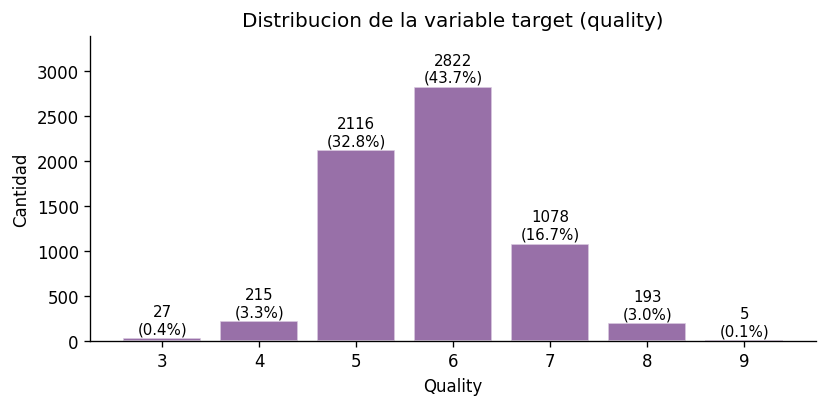

In [15]:
counts = df_clean["quality"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(counts.index.astype(str), counts.values, color="#6C3483", alpha=0.7, edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val}\n({100*val/len(df_clean):.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Quality")
ax.set_ylabel("Cantidad")
ax.set_title("Distribucion de la variable target (quality)")
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

### Estrategia: stratified split + k-fold cross-validation

**Paso 1 -- Separar test (holdout final):**

Reservamos un **20% del dataset como test set**, usando `train_test_split` con el
parametro `stratify=y`. Esto garantiza que la proporcion de cada valor de `quality`
en el test set sea la misma que en el dataset completo. El test set **no se toca**
hasta la evaluacion final.

**Nota sobre data leakage:** `stratify` **no** introduce data leakage. Solo le indica
a sklearn como repartir las filas para mantener la proporcion de cada clase, pero no
calcula ni aplica ninguna transformacion estadistica. Es una regla de asignacion, no
una operacion sobre los datos.

**Paso 2 -- K-Fold Cross-Validation estratificado sobre train (80%):**

Sobre el 80% restante aplicamos **Stratified K-Fold** (k=5) para generar los splits
de train/validation en cada fold. En cada iteracion:

- 4/5 del train se usa para entrenar.
- 1/5 se usa para validar.

`StratifiedKFold` mantiene la proporcion de cada valor de quality en cada fold,
evitando que un fold quede sin ejemplos de calidad 3 o 9.

**Por que stratified y no random:**

| quality | Total | Sin stratify (posible en un fold) | Con stratify (garantizado) |
|---------|-------|-----------------------------------|---------------------------|
| 3       | ~30   | 0-2 por fold                      | ~6 por fold               |
| 9       | ~5    | 0 en varios folds                 | ~1 por fold               |

Sin estratificacion, los folds con 0 ejemplos de calidad 3 o 9 darian metricas de
validacion que no reflejan la capacidad real del modelo en esos casos.

**Por que no se necesita un validation set fijo separado:**

El enunciado pide k-fold cross-validation, que ya genera multiples splits de
validacion. Un tercer conjunto fijo de validacion reduciria innecesariamente los datos
de entrenamiento (~6456 muestras ya es un dataset chico). El esquema es:

```
Dataset limpio (6456 filas)
   |
   |-- 80% Train (5165 filas) -- K-Fold CV estratificado (k=5)
   |       |-- Fold 1: train(4132) / val(1033)
   |       |-- Fold 2: train(4132) / val(1033)
   |       |-- ...
   |       |-- Fold 5: train(4132) / val(1033)
   |
   |-- 20% Test (1291 filas) -- Evaluacion final unica
```

In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df_clean.drop(columns=["quality"])
y = df_clean["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} filas  |  Test: {len(X_test)} filas")
print(f"\nDistribucion de quality en cada conjunto:\n")

split_dist = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Train %": (100 * y_train.value_counts().sort_index() / len(y_train)).round(1),
    "Test": y_test.value_counts().sort_index(),
    "Test %": (100 * y_test.value_counts().sort_index() / len(y_test)).round(1),
})
print(split_dist)

Train: 5164 filas  |  Test: 1292 filas

Distribucion de quality en cada conjunto:

         Train  Train %  Test  Test %
quality                              
3           22      0.4     5     0.4
4          172      3.3    43     3.3
5         1693     32.8   423    32.7
6         2257     43.7   565    43.7
7          862     16.7   216    16.7
8          154      3.0    39     3.0
9            4      0.1     1     0.1


In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Verificacion de la distribucion de quality en cada fold:\n")

fold_data = {}
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    fold_data[f"Fold {fold} train"] = len(y_fold_train)
    fold_data[f"Fold {fold} val"] = len(y_fold_val)
    print(f"Fold {fold}: train={len(y_fold_train)}, val={len(y_fold_val)}  |  "
          f"val quality dist: {dict(y_fold_val.value_counts().sort_index())}")

Verificacion de la distribucion de quality en cada fold:

Fold 1: train=4131, val=1033  |  val quality dist: {3: np.int64(4), 4: np.int64(34), 5: np.int64(339), 6: np.int64(451), 7: np.int64(173), 8: np.int64(31), 9: np.int64(1)}
Fold 2: train=4131, val=1033  |  val quality dist: {3: np.int64(5), 4: np.int64(34), 5: np.int64(339), 6: np.int64(451), 7: np.int64(173), 8: np.int64(30), 9: np.int64(1)}
Fold 3: train=4131, val=1033  |  val quality dist: {3: np.int64(5), 4: np.int64(34), 5: np.int64(339), 6: np.int64(451), 7: np.int64(172), 8: np.int64(31), 9: np.int64(1)}
Fold 4: train=4131, val=1033  |  val quality dist: {3: np.int64(4), 4: np.int64(35), 5: np.int64(338), 6: np.int64(452), 7: np.int64(172), 8: np.int64(31), 9: np.int64(1)}
Fold 5: train=4132, val=1032  |  val quality dist: {3: np.int64(4), 4: np.int64(35), 5: np.int64(338), 6: np.int64(452), 7: np.int64(172), 8: np.int64(31)}


### Preprocesamiento: winsorizacion y escalado

Tanto la winsorizacion como el escalado son transformaciones que dependen de
**estadisticas calculadas sobre los datos** (percentiles, media, desvio estandar).
Si las calcularamos sobre el dataset completo antes de separar, estariamos filtrando
informacion del test set al train set (**data leakage**).

Por eso, ambas transformaciones se ajustan (`fit`) **unicamente sobre X_train** y
luego se aplican (`transform`) a train y test por separado.

**Resumen de que introduce y que NO introduce data leakage:**

| Operacion | Usa estadisticas de los datos? | Cuando aplicar | Leakage si se hace antes? |
|-----------|-------------------------------|----------------|--------------------------|
| Eliminar filas erroneas (pH < 2.80, etc.) | No, usa umbrales fijos del dominio | Antes del split | No |
| Stratified split | No, solo asigna filas | En el split | No |
| Winsorizacion (p1, p99) | **Si**, calcula percentiles | Despues del split | **Si** |
| StandardScaler (media, std) | **Si**, calcula media y std | Despues del split | **Si** |

Veamos primero por que es necesario escalar:

In [18]:
ranges = pd.DataFrame({
    "min": X_train.min(),
    "max": X_train.max(),
    "rango": X_train.max() - X_train.min(),
    "media": X_train.mean(),
    "std": X_train.std()
}).round(4)

print(ranges.to_string())
print(f"\nEl rango mas chico es {ranges['rango'].min():.4f} ({ranges['rango'].idxmin()})")
print(f"El rango mas grande es {ranges['rango'].max():.1f} ({ranges['rango'].idxmax()})")
print(f"Ratio max/min de rangos: {ranges['rango'].max() / ranges['rango'].min():.0f}x")

                         min       max     rango     media      std
fixed acidity         3.8000   15.9000   12.1000    7.2181   1.2940
volatile acidity      0.0800    1.5800    1.5000    0.3400   0.1662
citric acid           0.0000    1.0000    1.0000    0.3175   0.1429
residual sugar        0.6000   26.0500   25.4500    5.4945   4.7050
chlorides             0.0120    0.2900    0.2780    0.0549   0.0274
free sulfur dioxide   1.0000  138.5000  137.5000   30.5508  17.3891
total sulfur dioxide  6.0000  282.0000  276.0000  115.8359  56.0561
density               0.9871    1.0037    0.0166    0.9947   0.0029
pH                    2.8000    4.0100    1.2100    3.2202   0.1599
sulphates             0.2200    1.9800    1.7600    0.5294   0.1436
alcohol               8.0000   14.9000    6.9000   10.4905   1.1874
red_wine_type         0.0000    1.0000    1.0000    0.2477   0.4317

El rango mas chico es 0.0166 (density)
El rango mas grande es 276.0 (total sulfur dioxide)
Ratio max/min de rangos:

Las variables tienen rangos que difieren en ordenes de magnitud. Sin escalado:

- **Regresion lineal sin regularizacion:** los coeficientes absorben la diferencia de
  escala, por lo que el modelo da el mismo resultado con o sin escalado. Sin embargo,
  los coeficientes dejan de ser comparables entre si.
- **Regresion con regularizacion (Lasso):** el termino de penalizacion L1 trata todos
  los coeficientes por igual. Sin escalado, las variables con rango grande tendrian
  coeficientes naturalmente chicos y serian menos penalizadas, mientras que las de
  rango chico (como `density`) serian injustamente penalizadas. **Escalar es
  obligatorio** para que la regularizacion funcione correctamente.
- **Regresion polinomica:** los terminos de grado 2+ amplifican las diferencias de
  escala exponencialmente, causando problemas numericos.

**Metodo elegido: `StandardScaler`** (estandarizacion a media=0, desvio=1). Se prefiere
sobre `MinMaxScaler` porque no asume un rango fijo, lo que lo hace mas robusto ante
valores de test que caigan fuera del rango observado en train.

**Pipeline de preprocesamiento (todo ajustado solo sobre train):**

```
X_train, X_test
   |
   |-- 1. Winsorizar: calcular p1/p99 en X_train, aplicar clip a ambos
   |-- 2. Escalar: fit StandardScaler en X_train, transform ambos
   |
X_train_scaled, X_test_scaled
```

In [19]:
import os
from sklearn.preprocessing import StandardScaler

# --- 1. Winsorizacion (ajustada solo sobre train) ---
cols_to_winsorize = ["residual sugar", "volatile acidity", "sulphates", "chlorides"]

for col in cols_to_winsorize:
    p1  = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    n_train = ((X_train[col] < p1) | (X_train[col] > p99)).sum()
    n_test  = ((X_test[col] < p1) | (X_test[col] > p99)).sum()
    X_train[col] = X_train[col].clip(lower=p1, upper=p99)
    X_test[col]  = X_test[col].clip(lower=p1, upper=p99)
    print(f"  {col}: p1={p1:.4f}, p99={p99:.4f} | train: {n_train} winsorizados, test: {n_test} winsorizados")

# --- 2. Escalado (ajustado solo sobre train) ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print("\nVerificacion post-escalado (X_train_scaled):\n")
check = pd.DataFrame({
    "media": X_train_scaled.mean(),
    "std":   X_train_scaled.std(),
    "min":   X_train_scaled.min(),
    "max":   X_train_scaled.max()
}).round(4)
print(check.to_string())

# --- 3. Exportar dataset limpio (pre-escalado, para referencia) ---
os.makedirs("data/processed", exist_ok=True)
df_export = pd.concat([X_train, X_test])
df_export["quality"] = pd.concat([y_train, y_test])
df_export.sort_index().to_csv("data/processed/wine_quality_clean.csv", index=False)
print(f"\nDataset limpio exportado: data/processed/wine_quality_clean.csv")

  residual sugar: p1=0.9000, p99=18.2000 | train: 76 winsorizados, test: 18 winsorizados
  volatile acidity: p1=0.1200, p99=0.8850 | train: 74 winsorizados, test: 16 winsorizados
  sulphates: p1=0.3000, p99=0.9700 | train: 91 winsorizados, test: 17 winsorizados
  chlorides: p1=0.0220, p99=0.1700 | train: 102 winsorizados, test: 42 winsorizados

Verificacion post-escalado (X_train_scaled):

                      media     std     min     max
fixed acidity          -0.0  1.0001 -2.6418  6.7102
volatile acidity       -0.0  1.0001 -1.3600  3.3947
citric acid            -0.0  1.0001 -2.2220  4.7760
residual sugar          0.0  1.0001 -0.9827  2.7284
chlorides              -0.0  1.0001 -1.2801  4.5349
free sulfur dioxide     0.0  1.0001 -1.6996  6.2085
total sulfur dioxide   -0.0  1.0001 -1.9596  2.9645
density                 0.0  1.0001 -2.5968  3.0611
pH                     -0.0  1.0001 -2.6288  4.9414
sulphates               0.0  1.0001 -1.6798  3.2557
alcohol                -0.0  1.0001


Dataset limpio exportado: data/processed/wine_quality_clean.csv
